In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("haideraqeeb/face-segmentation-dataset")

print("Path to dataset files:", path)

100%|██████████| 306M/306M [00:02<00:00, 136MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/haideraqeeb/face-segmentation-dataset/versions/1


In [2]:
!mv /root/.cache/kagglehub/datasets/haideraqeeb/face-segmentation-dataset/versions/1 /content

In [3]:
!mv /content/1/sorted_data/sorted_data/ /content/

In [4]:
!rm -r /content/1

In [5]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Flatten, Dense
from keras.applications.vgg16 import VGG16

In [27]:
conv_base = VGG16(
    weights = 'imagenet',
    include_top = False,
    input_shape = (150, 150, 3)
)

In [28]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

In [29]:
conv_base.trainable = False

In [30]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [31]:
# generators
dataset = keras.utils.image_dataset_from_directory(
    directory="/content/sorted_data/",
    labels="inferred",
    label_mode="int",  # or "binary" if using binary_crossentropy
    batch_size=32,
    image_size=(150, 150),
    shuffle=True
)

Found 2878 files belonging to 2 classes.


In [32]:
val_split = 0.2
train_ds = keras.utils.image_dataset_from_directory(
    directory="/content/sorted_data/",
    validation_split=val_split,
    subset="training",
    seed=123,
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(150, 150),
    shuffle=True
)

test_ds = keras.utils.image_dataset_from_directory(
    directory="/content/sorted_data/",
    validation_split=val_split,
    subset="validation",
    seed=123,
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(150, 150),
    shuffle=True
)


Found 2878 files belonging to 2 classes.
Using 2303 files for training.
Found 2878 files belonging to 2 classes.
Using 575 files for validation.


In [33]:
def process(image, label):
  image = tf.cast(image/255., tf.float32)
  return image, label

train_ds = train_ds.map(process)
test_ds = test_ds.map(process)

In [34]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [35]:
history = model.fit(train_ds, epochs=10, validation_data=test_ds)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 15s 169ms/step - accuracy: 0.7712 - loss: 0.7124 - val_accuracy: 0.8226 - val_loss: 0.4225
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 151ms/step - accuracy: 0.8366 - loss: 0.3807 - val_accuracy: 0.8209 - val_loss: 0.4109
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 157ms/step - accuracy: 0.8270 - loss: 0.3841 - val_accuracy: 0.8330 - val_loss: 0.4048
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 148ms/step - accuracy: 0.8422 - loss: 0.3728 - val_accuracy: 0.8348 - val_loss: 0.4003
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 141ms/step - accuracy: 0.8390 - loss: 0.3652 - val_accuracy: 0.8296 - val_loss: 0.4044
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 21s 148ms/step - accuracy: 0.8359 - loss: 0.3564 - val_accuracy: 0.8348 - val_loss: 0.3957
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 148ms/step - accuracy: 0.8366 - loss: 0.3516 - val_accuracy: 0.8209 - val_loss: 0.4143
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 156ms/step - accuracy: 0.8446 - loss: 0.3466 - val_accu

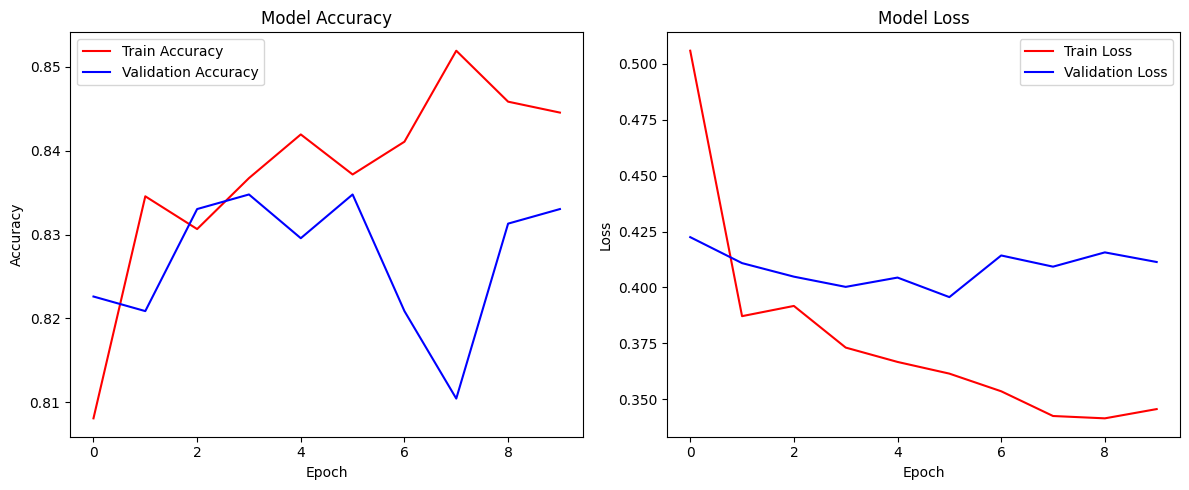

In [36]:
import matplotlib.pyplot as plt

# Create a figure with 2 subplots: one for accuracy, one for loss
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy plot
axs[0].plot(history.history['accuracy'], color='red', label='Train Accuracy')
axs[0].plot(history.history['val_accuracy'], color='blue', label='Validation Accuracy')
axs[0].set_title('Model Accuracy')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].legend()

# Loss plot
axs[1].plot(history.history['loss'], color='red', label='Train Loss')
axs[1].plot(history.history['val_loss'], color='blue', label='Validation Loss')
axs[1].set_title('Model Loss')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend()

# Show the plots
plt.tight_layout()
plt.show()


In [37]:
model.save("Confidence Prediction.h5")

### Fine Tuning

In [17]:
conv_base = VGG16(
    weights = 'imagenet',
    include_top = False,
    input_shape = (150, 150, 3)
)

In [19]:
conv_base.trainable = True

set_trainable = False

for layer in conv_base.layers:
  if layer.name == 'block5_conv1':
    set_trainable = True

  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable = False

In [20]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

In [21]:
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate = 1e-05), # While Fine tuning its adviced to keep the learning rate very small
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [22]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 9,177,089 (35.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [23]:
history = model.fit(train_ds, epochs=10, validation_data=test_ds)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 18s 196ms/step - accuracy: 0.7945 - loss: 0.4938 - val_accuracy: 0.8261 - val_loss: 0.4078
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 151ms/step - accuracy: 0.8341 - loss: 0.3836 - val_accuracy: 0.8261 - val_loss: 0.4157
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 152ms/step - accuracy: 0.8387 - loss: 0.3616 - val_accuracy: 0.8296 - val_loss: 0.4018
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 151ms/step - accuracy: 0.8344 - loss: 0.3538 - val_accuracy: 0.8209 - val_loss: 0.4395
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 13s 182ms/step - accuracy: 0.8472 - loss: 0.3458 - val_accuracy: 0.8191 - val_loss: 0.4057
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 19s 160ms/step - accuracy: 0.8534 - loss: 0.3281 - val_accuracy: 0.8261 - val_loss: 0.4322
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 20s 152ms/step - accuracy: 0.8555 - loss: 0.3317 - val_accuracy: 0.8191 - val_loss: 0.4157
Epoch 8/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 151ms/step - accuracy: 0.8524 - loss: 0.3306 - val_accu

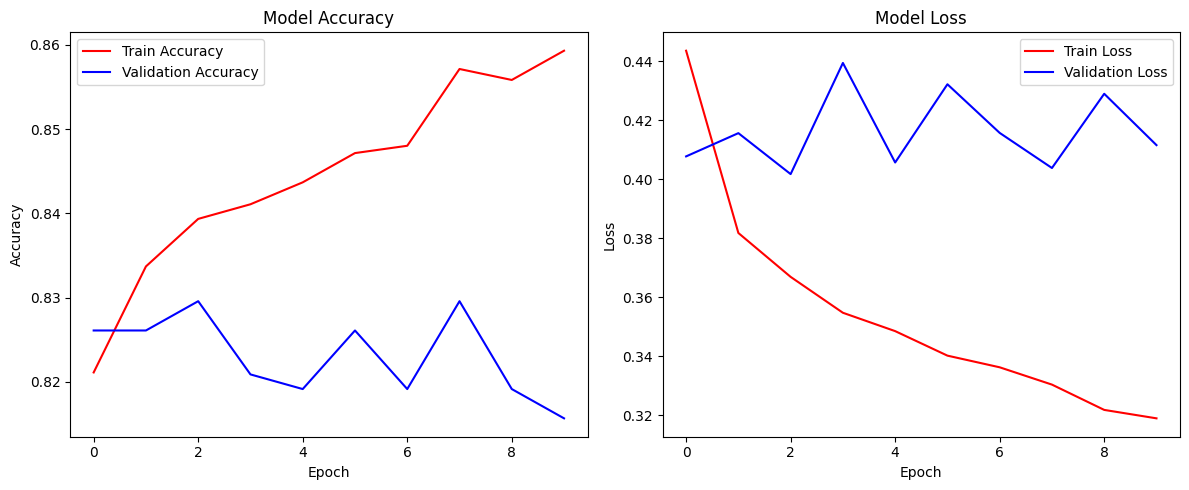

In [26]:
import matplotlib.pyplot as plt

# Create a figure with 2 subplots: one for accuracy, one for loss
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy plot
axs[0].plot(history.history['accuracy'], color='red', label='Train Accuracy')
axs[0].plot(history.history['val_accuracy'], color='blue', label='Validation Accuracy')
axs[0].set_title('Model Accuracy')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].legend()

# Loss plot
axs[1].plot(history.history['loss'], color='red', label='Train Loss')
axs[1].plot(history.history['val_loss'], color='blue', label='Validation Loss')
axs[1].set_title('Model Loss')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend()

# Show the plots
plt.tight_layout()
plt.show()


### Testing

In [46]:
model = keras.models.load_model('Confidence Prediction.h5')


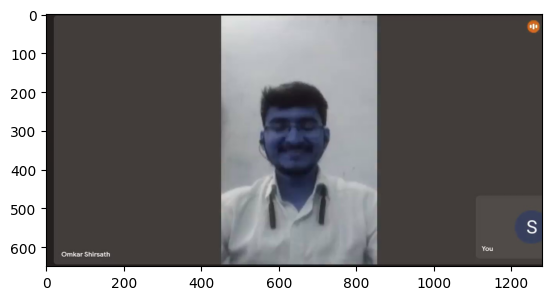

In [51]:
import cv2

# Confident Data
test_img = cv2.imread("/content/sorted_data/confident/1100.jpg")
plt.imshow(test_img)
test_img = cv2.resize(test_img, (150, 150))
test_img = test_img.reshape((1,150,150,3))

In [52]:
model.predict(test_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([[1.]], dtype=float32)

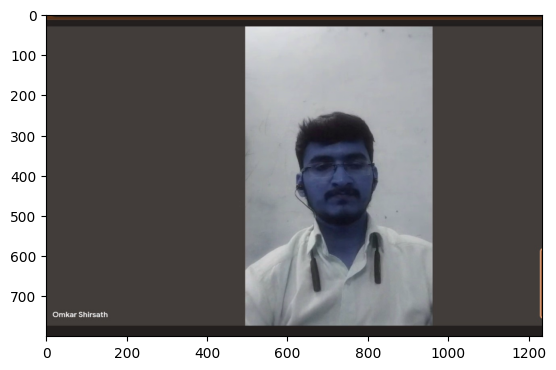

In [53]:
import cv2

# Confident Data
test_img = cv2.imread("/content/sorted_data/unconfident/1007.jpg")
plt.imshow(test_img)
test_img = cv2.resize(test_img, (150, 150))
test_img = test_img.reshape((1,150,150,3))

In [54]:
model.predict(test_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([[1.]], dtype=float32)

### From Kaggle

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import tensorflow as tf

In [56]:
from keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Model, Sequential
from keras.layers import Dense, Dropout, GlobalAveragePooling2D, Flatten
from tensorflow.keras.applications import VGG16
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

In [59]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sougatganguly/confident-unconfident")

print("Path to dataset files:", path)

100%|██████████| 62.2M/62.2M [00:00<00:00, 225MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sougatganguly/confident-unconfident/versions/1


In [60]:
!mv /root/.cache/kagglehub/datasets/sougatganguly/confident-unconfident/versions/1 /content/

In [61]:
picture_size = 48
folder_path = '/content/1/confident-unconfident'

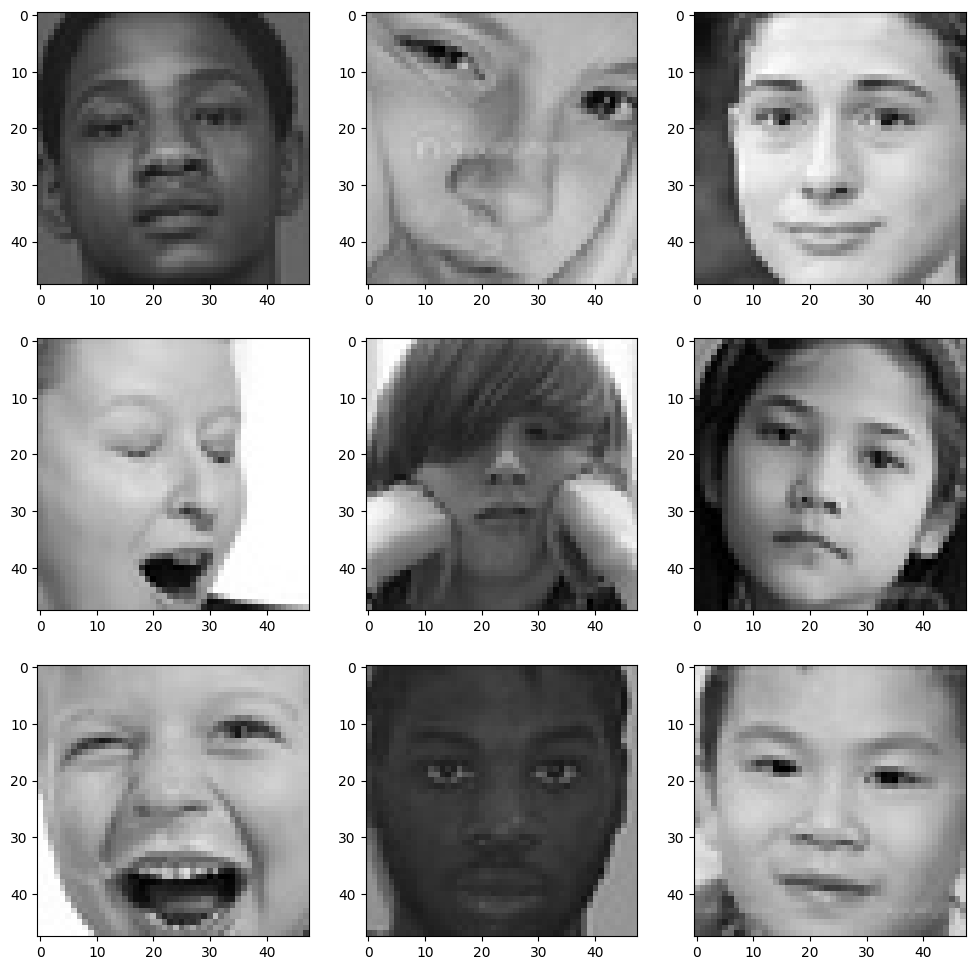

In [62]:
expression = 'confident'
plt.figure(figsize = (12, 12))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)
    img = load_img(folder_path + "/train/" + expression + "/" + os.listdir(folder_path + '/train/' + expression)[i],
                   target_size = (picture_size, picture_size))
    plt.imshow(img)
plt.show()

In [63]:
batch_size = 64
datagen_train = ImageDataGenerator(rescale=1./255,
                                   rotation_range=20,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True,
                                   validation_split=0.2)

datagen_val = ImageDataGenerator(horizontal_flip=True)

train_set = datagen_train.flow_from_directory(folder_path + "/train",
                                          target_size = (picture_size, picture_size),
                                          color_mode = 'grayscale',
                                          batch_size = batch_size,
                                          class_mode = 'binary',
                                            subset = 'training',
                                          shuffle = True)

val_set = datagen_train.flow_from_directory(folder_path + "/train",
                                            target_size=(picture_size, picture_size),
                                            color_mode='grayscale',
                                            batch_size=batch_size,
                                            class_mode='binary',
                                            subset='validation',  # Dữ liệu cho tập validation
                                            shuffle=False)

test_set = datagen_train.flow_from_directory(folder_path + "/train",
                                           target_size = (picture_size, picture_size),
                                           color_mode = 'grayscale',
                                           batch_size = batch_size,
                                           class_mode = 'binary',
                                           shuffle = False)

Found 22967 images belonging to 2 classes.
Found 5740 images belonging to 2 classes.
Found 28707 images belonging to 2 classes.


In [66]:
from keras.optimizers import Adam, SGD, RMSprop
from keras.regularizers import l2
from keras.layers import Conv2D, BatchNormalization, Activation, MaxPooling2D, Dropout, Flatten, Dense

model = Sequential()

# 1 - Convolution layer
model.add(Conv2D(64,(3,3), padding='same', input_shape=(48, 48, 1)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# 2nd Convolution layer
model.add(Conv2D(128,(5,5), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# 3rd Convolution layer
model.add(Conv2D(512,(3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# 4th Convolution layer
model.add(Conv2D(512,(3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Flattening
model.add(Flatten())

# Fully connected layer 1st layer
model.add(Dense(256))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))

# Fully connected layer 2nd layer
model.add(Dense(512))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))

model.add(Dense(1, activation='sigmoid'))

opt = Adam(0.01)
model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,02

 Total params: 4,475,649 (17.07 MB)

 Trainable params: 4,471,681 (17.06 MB)

 Non-trainable params: 3,968 (15.50 KB)

In [67]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint('./model.keras', monitor = 'val_acc', verbose = 1, save_best_only = True, mode = 'max')

early_stopping = EarlyStopping(monitor = 'val_loss',
                              min_delta = 0,
                              patience = 10,
                              verbose = 1,
                              restore_best_weights = True)
reduce_learningrate = ReduceLROnPlateau(monitor = 'val_loss',
                                       factor = 0.2,
                                       patience = 3,
                                       verbose = 1,
                                       min_delta = 0.0001)
callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

In [68]:
epochs = 20

history = model.fit(
    train_set,
    epochs=epochs,
    validation_data = val_set,
    callbacks=callbacks_list
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 56s 116ms/step - accuracy: 0.5364 - loss: 0.7730 - val_accuracy: 0.5031 - val_loss: 0.6933 - learning_rate: 0.0100
Epoch 2/20
  2/359 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.4961 - loss: 0.6881

/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/model_checkpoint.py:209: UserWarning: Can save best model only with val_acc available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


359/359 ━━━━━━━━━━━━━━━━━━━━ 27s 75ms/step - accuracy: 0.5702 - loss: 0.6874 - val_accuracy: 0.5761 - val_loss: 0.6748 - learning_rate: 0.0100
Epoch 3/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 27s 74ms/step - accuracy: 0.5861 - loss: 0.6687 - val_accuracy: 0.6115 - val_loss: 0.6574 - learning_rate: 0.0100
Epoch 4/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 27s 74ms/step - accuracy: 0.6169 - loss: 0.6483 - val_accuracy: 0.6207 - val_loss: 0.6479 - learning_rate: 0.0100
Epoch 5/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 28s 78ms/step - accuracy: 0.6430 - loss: 0.6307 - val_accuracy: 0.6357 - val_loss: 0.6375 - learning_rate: 0.0100
Epoch 6/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.6680 - loss: 0.6045 - val_accuracy: 0.6166 - val_loss: 0.6854 - learning_rate: 0.0100
Epoch 7/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 27s 74ms/step - accuracy: 0.6793 - loss: 0.5931 - val_accuracy: 0.6324 - val_loss: 0.6584 - learning_rate: 0.0100
Epoch 8/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 27s 74ms/step - accuracy: 0.6970 - loss: 0.5768

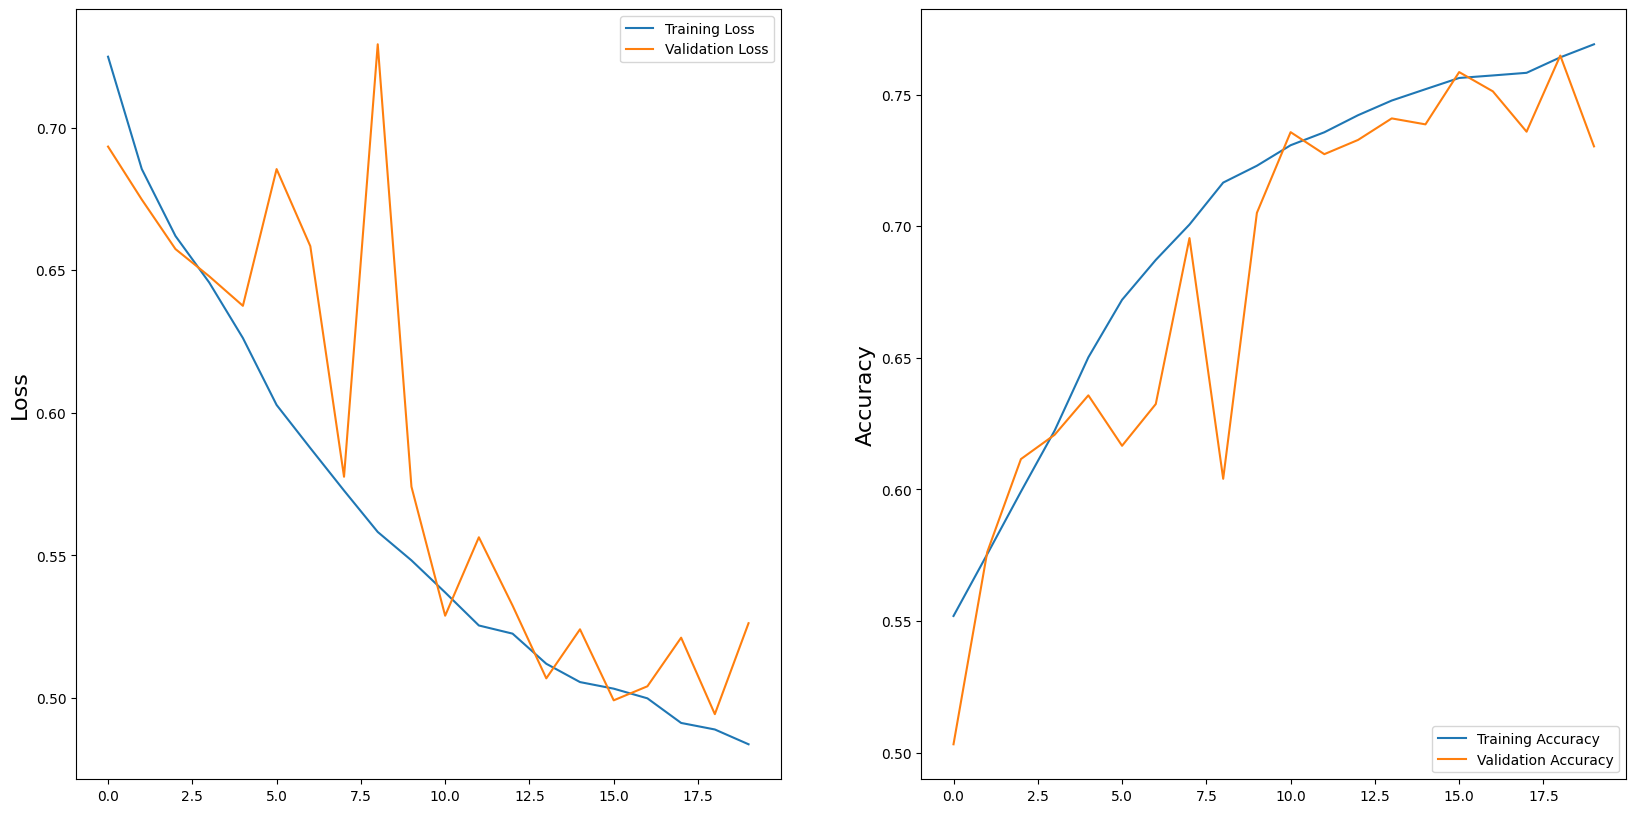

In [69]:
plt.figure(figsize = (20, 10))
plt.subplot(1, 2, 1)

plt.ylabel('Loss', fontsize = 16)
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.legend(loc = 'upper right')

plt.subplot(1, 2, 2)
plt.ylabel('Accuracy', fontsize = 16)
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.legend(loc = 'lower right')
plt.show()

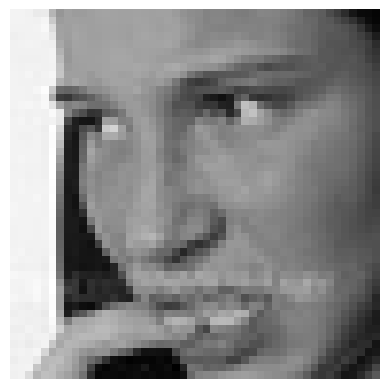

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted class index: 0


In [87]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img_path = "/content/1/confident-unconfident/train/unconfident/Training_10018621.jpg"
test_img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Load as grayscale
plt.imshow(test_img, cmap='gray')
plt.axis('off')
plt.show()

# Resize and preprocess
test_img = cv2.resize(test_img, (48, 48))
test_img = test_img / 255.0  # Normalize pixel values to [0, 1]
test_img = test_img.reshape((1, 48, 48, 1))  # Add batch and channel dims

# Predict
prediction = model.predict(test_img)
predicted_class = np.argmax(prediction)

print("Predicted class index:", predicted_class)
